## 1) Setup

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
#import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time
import warnings

warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.backends.cudnn.deterministic = True

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.7.1+cu118
CUDA available: True


## 2) Config

In [4]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 9
EPOCHS = 20
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SPLIT_DATA_DIR = 'data'

RESULTS_DIR = 'results'
MODELS_DIR = os.path.join(RESULTS_DIR, 'models')
VIZ_DIR = os.path.join(RESULTS_DIR, 'visualizations')
PART1_DIR = os.path.join(RESULTS_DIR, 'part1')
PART2_DIR = os.path.join(RESULTS_DIR, 'part2')

for directory in [RESULTS_DIR, MODELS_DIR, VIZ_DIR, PART1_DIR, PART2_DIR]:
    os.makedirs(directory, exist_ok=True)

## 3) Data

In [22]:
def get_data_loaders():
    train_transform = transforms.Compose([
        transforms.Resize(IMAGE_SIZE),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    val_test_transform = transforms.Compose([
        transforms.Resize(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    train_dataset = datasets.ImageFolder(
        root=os.path.join(SPLIT_DATA_DIR, 'train'),
        transform=train_transform
    )
    
    val_dataset = datasets.ImageFolder(
        root=os.path.join(SPLIT_DATA_DIR, 'validation'),
        transform=val_test_transform
    )
    
    test_dataset = datasets.ImageFolder(
        root=os.path.join(SPLIT_DATA_DIR, 'test'),
        transform=val_test_transform
    )
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    
    return train_loader, val_loader, test_loader, train_dataset.classes

train_loader, val_loader, test_loader, class_names = get_data_loaders()

print(f"Training samples: {len(train_loader.dataset)}")
print(f"Validation samples: {len(val_loader.dataset)}")
print(f"Test samples: {len(test_loader.dataset)}")
print(f"Classes: {class_names}")

Training samples: 4341
Validation samples: 1319
Test samples: 1338
Classes: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']


## 4) Model
Small CNN: 4 conv blocks + 3 FC. Dropout + BN. Gets the job done.

In [15]:
class WasteCustom(nn.Module):
    def __init__(self, num_classes=9):
        super(WasteCustom, self).__init__()
        
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.flatten = nn.Flatten()
        self.adaptive_pool = nn.AdaptiveAvgPool2d((8, 8))
        
        self.fc1 = nn.Linear(8192, 512)
        self.dropout1 = nn.Dropout(p=0.3)
        
        self.fc2 = nn.Linear(512, num_classes)
        self.relu = nn.Mish()
    
    def forward(self, x):
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        x = self.pool3(self.relu(self.conv3(x)))
        x = self.adaptive_pool(x)
        x = self.flatten(x)
        x = self.dropout1(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

model = WasteCustom(num_classes=NUM_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())

print(f"Total Parameters: {total_params:,}")
print("Architecture: 3 Conv blocks + 2 FC layers (no BN)")

Total Parameters: 4,292,681
Architecture: 3 Conv blocks + 2 FC layers (no BN)


## 5) Train utils

In [7]:
def train_one_epoch(model, dataloader, criterion, optimizer, device, current_lr, show_progress=False):
    model.train()
    running_loss, running_correct, total = 0.0, 0, 0
    batch_losses, batch_accs = [], []

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        batch_loss = loss.item()
        batch_losses.append(batch_loss)

        _, preds = torch.max(outputs, 1)
        batch_correct = (preds == labels).sum().item()
        batch_acc = batch_correct / inputs.size(0)
        batch_accs.append(batch_acc)

        running_loss += loss.item() * inputs.size(0)
        running_correct += batch_correct
        total += inputs.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc


def validate(model, dataloader, criterion, device, show_progress=False):
    model.eval()
    running_loss, running_correct, total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            running_correct += (preds == labels).sum().item()
            total += inputs.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc

In [11]:
def train_model(model, train_loader, val_loader, optimizer, criterion, epochs, device, model_name, use_scheduler=True):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'learning_rates': []}
    best_val_acc = 0.0
    scheduler = None
    if use_scheduler:
        scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer, T_0=22, T_mult=1, eta_min=1e-6
        )

    for epoch in range(epochs):
        lr = optimizer.param_groups[0]['lr']
        history['learning_rates'].append(lr)

        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device, lr)
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if scheduler is not None:
            scheduler.step()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), os.path.join(MODELS_DIR, f'best_model_{model_name}.pth'))

        print(f"epoch {epoch+1:02d}/{epochs} | lr {lr:.6f} | train {train_loss:.4f}/{train_acc:.4f} | val {val_loss:.4f}/{val_acc:.4f}")

    print(f"best val acc: {best_val_acc:.4f} -> saved: {os.path.join(MODELS_DIR, f'best_model_{model_name}.pth')}")
    return history, best_val_acc

## 6) Train: Adam

In [21]:
model_adam = WasteCustom(num_classes=NUM_CLASSES).to(DEVICE)
optimizer_adam = optim.Adam(model_adam.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

adam_history, adam_best_acc = train_model(
    model=model_adam,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_adam,
    criterion=criterion,
    epochs=EPOCHS,
    device=DEVICE,
    model_name='WasteCustom_Adam',
    use_scheduler=True
)

epoch 01/20 | lr 0.001000 | train 1.7617/0.3564 | val 1.4071/0.4655
epoch 02/20 | lr 0.000995 | train 1.4406/0.4891 | val 1.1207/0.5974
epoch 03/20 | lr 0.000980 | train 1.3120/0.5243 | val 1.2777/0.5497
epoch 04/20 | lr 0.000955 | train 1.1857/0.5713 | val 0.9303/0.6611
epoch 05/20 | lr 0.000921 | train 1.0855/0.6047 | val 0.8505/0.6937
epoch 06/20 | lr 0.000878 | train 1.0547/0.6264 | val 0.9217/0.6664
epoch 07/20 | lr 0.000828 | train 0.9715/0.6485 | val 0.8589/0.6876
epoch 08/20 | lr 0.000771 | train 0.9205/0.6690 | val 0.7257/0.7384
epoch 09/20 | lr 0.000708 | train 0.8347/0.6957 | val 0.6814/0.7536
epoch 10/20 | lr 0.000641 | train 0.8007/0.7116 | val 0.5697/0.8021
epoch 11/20 | lr 0.000572 | train 0.7216/0.7365 | val 0.5276/0.8059
epoch 12/20 | lr 0.000501 | train 0.6626/0.7625 | val 0.5118/0.8256
epoch 13/20 | lr 0.000429 | train 0.6227/0.7777 | val 0.5090/0.8302
epoch 14/20 | lr 0.000360 | train 0.5793/0.7913 | val 0.4330/0.8431
epoch 15/20 | lr 0.000293 | train 0.5123/0.8215 

## 7) Train: SGD

In [ ]:
model_sgd = WasteCustom(num_classes=NUM_CLASSES).to(DEVICE)
optimizer_sgd = optim.SGD(model_sgd.parameters(), lr=0.01, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

sgd_history, sgd_best_acc = train_model(
    model=model_sgd,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_sgd,
    criterion=criterion,
    epochs=EPOCHS,
    device=DEVICE,
    model_name='WasteCustom_SGD',
    use_scheduler=True
)

epoch 01/20 | lr 0.000500 | train 2.1944/0.1454 | val 2.1938/0.1933
epoch 02/20 | lr 0.000497 | train 2.1922/0.1871 | val 2.1916/0.2206
epoch 03/20 | lr 0.000490 | train 2.1898/0.2055 | val 2.1894/0.2092
epoch 04/20 | lr 0.000477 | train 2.1875/0.2110 | val 2.1874/0.1994
epoch 05/20 | lr 0.000460 | train 2.1857/0.2076 | val 2.1854/0.1971
epoch 06/20 | lr 0.000439 | train 2.1837/0.2073 | val 2.1836/0.1971
epoch 07/20 | lr 0.000414 | train 2.1818/0.2050 | val 2.1818/0.1956
epoch 08/20 | lr 0.000385 | train 2.1801/0.2009 | val 2.1802/0.1948
epoch 09/20 | lr 0.000354 | train 2.1784/0.2018 | val 2.1787/0.1948
epoch 10/20 | lr 0.000321 | train 2.1767/0.1995 | val 2.1774/0.1941
epoch 11/20 | lr 0.000286 | train 2.1760/0.1974 | val 2.1762/0.1941
epoch 12/20 | lr 0.000251 | train 2.1746/0.1981 | val 2.1751/0.1941


KeyboardInterrupt: 

## 8) Train: SGD+Momentum

In [71]:
model_sgd_momentum = WasteCustom(num_classes=NUM_CLASSES).to(DEVICE)
optimizer_sgd_momentum = optim.SGD(model_sgd_momentum.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

sgd_momentum_history, sgd_momentum_best_acc = train_model(
    model=model_sgd_momentum,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_sgd_momentum,
    criterion=criterion,
    epochs=EPOCHS,
    device=DEVICE,
    model_name='WasteCustom_SGD_Momentum',
    use_scheduler=True
)

epoch 01/20 | lr 0.010000 | train 1.6477/0.4029 | val 1.6960/0.4071
epoch 02/20 | lr 0.009755 | train 1.3876/0.4994 | val 1.1610/0.6058
epoch 02/20 | lr 0.009755 | train 1.3876/0.4994 | val 1.1610/0.6058
epoch 03/20 | lr 0.009045 | train 1.2524/0.5536 | val 1.1788/0.5845
epoch 03/20 | lr 0.009045 | train 1.2524/0.5536 | val 1.1788/0.5845
epoch 04/20 | lr 0.007939 | train 1.1687/0.5727 | val 0.8720/0.6914
epoch 04/20 | lr 0.007939 | train 1.1687/0.5727 | val 0.8720/0.6914
epoch 05/20 | lr 0.006545 | train 1.0870/0.6019 | val 0.8449/0.6945
epoch 05/20 | lr 0.006545 | train 1.0870/0.6019 | val 0.8449/0.6945
epoch 06/20 | lr 0.005001 | train 1.0024/0.6365 | val 0.7572/0.7293
epoch 06/20 | lr 0.005001 | train 1.0024/0.6365 | val 0.7572/0.7293
epoch 07/20 | lr 0.003456 | train 0.9252/0.6586 | val 0.8593/0.6854
epoch 07/20 | lr 0.003456 | train 0.9252/0.6586 | val 0.8593/0.6854
epoch 08/20 | lr 0.002062 | train 0.8435/0.6911 | val 0.6653/0.7483
epoch 08/20 | lr 0.002062 | train 0.8435/0.6911 

## 9) Optimizer curves

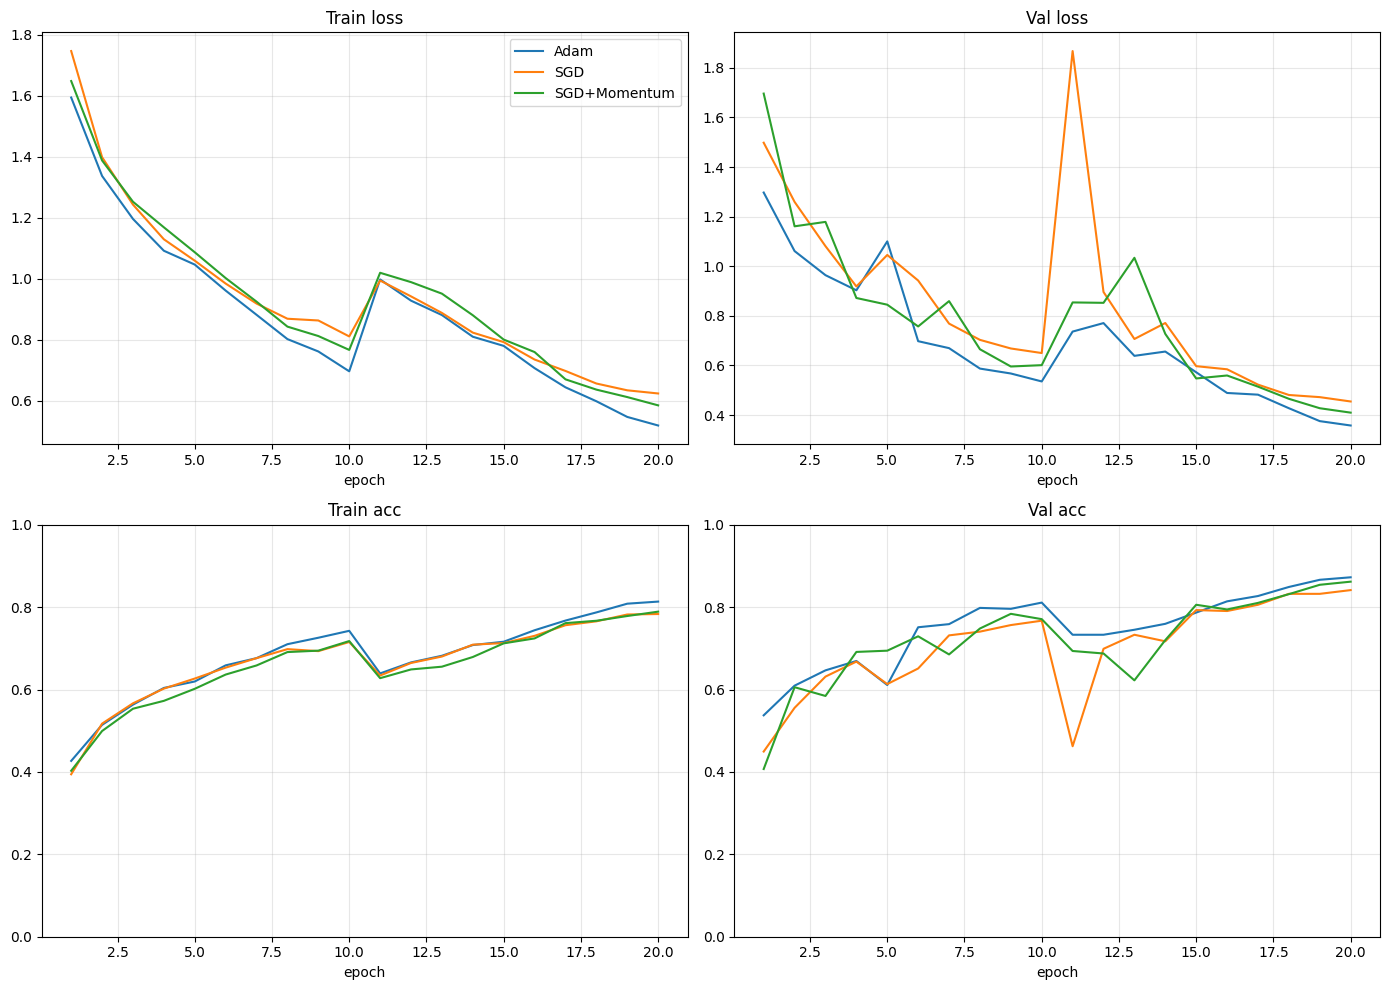

In [72]:
def plot_optimizer_comparison(histories, names, save_path=None):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    epochs = range(1, len(histories[0]['train_loss']) + 1)

    for h, n in zip(histories, names):
        axes[0, 0].plot(epochs, h['train_loss'], label=n)
    axes[0, 0].set_title('Train loss')

    for h, n in zip(histories, names):
        axes[0, 1].plot(epochs, h['val_loss'], label=n)
    axes[0, 1].set_title('Val loss')

    for h, n in zip(histories, names):
        axes[1, 0].plot(epochs, h['train_acc'], label=n)
    axes[1, 0].set_title('Train acc')
    axes[1, 0].set_ylim([0, 1])

    for h, n in zip(histories, names):
        axes[1, 1].plot(epochs, h['val_acc'], label=n)
    axes[1, 1].set_title('Val acc')
    axes[1, 1].set_ylim([0, 1])

    for ax in axes.ravel():
        ax.grid(True, alpha=0.3)
        ax.set_xlabel('epoch')

    axes[0, 0].legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

plot_optimizer_comparison(
    histories=[adam_history, sgd_history, sgd_momentum_history],
    names=['Adam', 'SGD', 'SGD+Momentum'],
    save_path=os.path.join(PART1_DIR, 'optimizer_comparison.png')
)

## 10) Test eval (all optimizers)

In [74]:
import time

print("="*80)
print("EVALUATING ALL OPTIMIZERS ON TEST SET")
print("="*80)

# Function to evaluate model on test set
def evaluate_on_test_set(model, test_loader, criterion, device, model_name):
    """Evaluate model on test set and return metrics"""
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    
    start_time = time.time()
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            test_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    inference_time = time.time() - start_time
    
    test_accuracy = correct / total
    avg_test_loss = test_loss / total
    
    print(f"\n{model_name}:")
    print(f"  Test Accuracy:     {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
    print(f"  Test Loss:         {avg_test_loss:.4f}")
    print(f"  Inference Time:    {inference_time:.2f}s")
    print(f"  Correct/Total:     {correct}/{total}")
    
    return test_accuracy, avg_test_loss, inference_time

# Define criterion for evaluation
criterion = nn.CrossEntropyLoss()

# Evaluate Adam Model
adam_test_acc, adam_test_loss, adam_inference_time = evaluate_on_test_set(
    model_adam, test_loader, criterion, DEVICE, "Adam Optimizer"
)

# Evaluate SGD Model
sgd_test_acc, sgd_test_loss, sgd_inference_time = evaluate_on_test_set(
    model_sgd, test_loader, criterion, DEVICE, "SGD Optimizer"
)

# Evaluate SGD with Momentum Model
sgd_mom_test_acc, sgd_mom_test_loss, sgd_mom_inference_time = evaluate_on_test_set(
    model_sgd_momentum, test_loader, criterion, DEVICE, "SGD with Momentum"
)

print("\n" + "="*80)
print("TEST SET EVALUATION COMPLETED")
print("="*80)

EVALUATING ALL OPTIMIZERS ON TEST SET

Adam Optimizer:
  Test Accuracy:     0.8842 (88.42%)
  Test Loss:         0.3546
  Inference Time:    8.76s
  Correct/Total:     1183/1338

Adam Optimizer:
  Test Accuracy:     0.8842 (88.42%)
  Test Loss:         0.3546
  Inference Time:    8.76s
  Correct/Total:     1183/1338

SGD Optimizer:
  Test Accuracy:     0.8572 (85.72%)
  Test Loss:         0.4324
  Inference Time:    8.29s
  Correct/Total:     1147/1338

SGD Optimizer:
  Test Accuracy:     0.8572 (85.72%)
  Test Loss:         0.4324
  Inference Time:    8.29s
  Correct/Total:     1147/1338

SGD with Momentum:
  Test Accuracy:     0.8722 (87.22%)
  Test Loss:         0.3901
  Inference Time:    8.43s
  Correct/Total:     1167/1338

TEST SET EVALUATION COMPLETED

SGD with Momentum:
  Test Accuracy:     0.8722 (87.22%)
  Test Loss:         0.3901
  Inference Time:    8.43s
  Correct/Total:     1167/1338

TEST SET EVALUATION COMPLETED


### Metrics

In [75]:
# Collect comprehensive metrics for all three optimizers
optimizer_comparison = {
    'Adam': {
        'test_accuracy': adam_test_acc,
        'test_loss': adam_test_loss,
        'final_train_acc': adam_history['train_acc'][-1],
        'final_val_acc': adam_history['val_acc'][-1],
        'best_val_acc': max(adam_history['val_acc']),
        'final_train_loss': adam_history['train_loss'][-1],
        'final_val_loss': adam_history['val_loss'][-1],
        'epochs_trained': len(adam_history['train_acc']),
        'inference_time': adam_inference_time,
        'train_val_acc_gap': adam_history['train_acc'][-1] - adam_history['val_acc'][-1],
        'train_test_acc_gap': adam_history['train_acc'][-1] - adam_test_acc
    },
    'SGD': {
        'test_accuracy': sgd_test_acc,
        'test_loss': sgd_test_loss,
        'final_train_acc': sgd_history['train_acc'][-1],
        'final_val_acc': sgd_history['val_acc'][-1],
        'best_val_acc': max(sgd_history['val_acc']),
        'final_train_loss': sgd_history['train_loss'][-1],
        'final_val_loss': sgd_history['val_loss'][-1],
        'epochs_trained': len(sgd_history['train_acc']),
        'inference_time': sgd_inference_time,
        'train_val_acc_gap': sgd_history['train_acc'][-1] - sgd_history['val_acc'][-1],
        'train_test_acc_gap': sgd_history['train_acc'][-1] - sgd_test_acc
    },
    'SGD + Momentum': {
        'test_accuracy': sgd_mom_test_acc,
        'test_loss': sgd_mom_test_loss,
        'final_train_acc': sgd_momentum_history['train_acc'][-1],
        'final_val_acc': sgd_momentum_history['val_acc'][-1],
        'best_val_acc': max(sgd_momentum_history['val_acc']),
        'final_train_loss': sgd_momentum_history['train_loss'][-1],
        'final_val_loss': sgd_momentum_history['val_loss'][-1],
        'epochs_trained': len(sgd_momentum_history['train_acc']),
        'inference_time': sgd_mom_inference_time,
        'train_val_acc_gap': sgd_momentum_history['train_acc'][-1] - sgd_momentum_history['val_acc'][-1],
        'train_test_acc_gap': sgd_momentum_history['train_acc'][-1] - sgd_mom_test_acc
    }
}

print("\nMetrics collected successfully for all optimizers!")


Metrics collected successfully for all optimizers!


### Compare at a glance

In [77]:
print("== Optimizer comparison ==")
print(f"{'opt':<18} {'test_acc':<10} {'test_loss':<10} {'inference(s)':<12}")
for opt, m in optimizer_comparison.items():
    print(f"{opt:<18} {m['test_accuracy']:.4f} {m['test_loss']:.4f} {m['inference_time']:.2f}")

best_test_acc = max(optimizer_comparison.items(), key=lambda x: x[1]['test_accuracy'])
best_test_loss = min(optimizer_comparison.items(), key=lambda x: x[1]['test_loss'])
best_generalization = min(optimizer_comparison.items(), key=lambda x: x[1]['train_test_acc_gap'])
fastest_inference = min(optimizer_comparison.items(), key=lambda x: x[1]['inference_time'])

print("\nBest:")
print(f"acc -> {best_test_acc[0]} ({best_test_acc[1]['test_accuracy']*100:.2f}%)")
print(f"loss -> {best_test_loss[0]} ({best_test_loss[1]['test_loss']:.4f})")
print(f"gen  -> {best_generalization[0]} (gap {best_generalization[1]['train_test_acc_gap']:.4f})")
print(f"speed-> {fastest_inference[0]} ({fastest_inference[1]['inference_time']:.2f}s)")

== Optimizer comparison ==
opt                test_acc   test_loss  inference(s)
Adam               0.8842 0.3546 8.76
SGD                0.8572 0.4324 8.29
SGD + Momentum     0.8722 0.3901 8.43

Best:
acc -> Adam (88.42%)
loss -> Adam (0.3546)
gen  -> SGD + Momentum (gap -0.0830)
speed-> SGD (8.29s)


In [80]:
adam_metrics = optimizer_comparison['Adam']
sgd_metrics = optimizer_comparison['SGD']
sgd_mom_metrics = optimizer_comparison['SGD + Momentum']

acc_ranking = sorted(optimizer_comparison.items(), key=lambda x: x[1]['test_accuracy'], reverse=True)
gen_ranking = sorted(optimizer_comparison.items(), key=lambda x: x[1]['train_test_acc_gap'])
loss_ranking = sorted(optimizer_comparison.items(), key=lambda x: x[1]['test_loss'])

print("Ranking (higher is better unless noted)")
print("- acc:")
for i, (name, m) in enumerate(acc_ranking, 1):
    print(f"  {i}. {name} -> {m['test_accuracy']*100:.2f}%")
print("- gen (lower gap):")
for i, (name, m) in enumerate(gen_ranking, 1):
    print(f"  {i}. {name} -> gap {m['train_test_acc_gap']:.4f}")
print("- loss (lower):")
for i, (name, m) in enumerate(loss_ranking, 1):
    print(f"  {i}. {name} -> {m['test_loss']:.4f}")

Ranking (higher is better unless noted)
- acc:
  1. Adam -> 88.42%
  2. SGD + Momentum -> 87.22%
  3. SGD -> 85.72%
- gen (lower gap):
  1. SGD + Momentum -> gap -0.0830
  2. SGD -> gap -0.0738
  3. Adam -> gap -0.0705
- loss (lower):
  1. Adam -> 0.3546
  2. SGD + Momentum -> 0.3901
  3. SGD -> 0.4324


## 11) Adam training

## 12) Test eval (best Adam)

In [82]:
import torch
import numpy as np
import os
import time

def evaluate_model(model, test_loader, criterion, device):
    model.eval()
    test_loss = 0.0
    preds, labels_all = [], []
    total = len(test_loader.dataset)

    start = time.time()
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item() * inputs.size(0)
            _, p = torch.max(outputs, 1)
            preds.extend(p.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    test_loss /= total
    test_acc = np.mean(np.array(preds) == np.array(labels_all))

    print(f"test loss: {test_loss:.4f} | test acc: {test_acc:.4f} ({test_acc*100:.2f}%)")
    return test_loss, test_acc, preds, labels_all


# Load and evaluate the best model
best_model_path = os.path.join(MODELS_DIR, 'best_model_WasteCustom_Adam.pth')
print(f"loading: {best_model_path}")

best_model = WasteCustom(num_classes=NUM_CLASSES).to(DEVICE)
best_model.load_state_dict(torch.load(best_model_path))

test_loss, test_acc, predictions, true_labels = evaluate_model(best_model, test_loader, criterion, DEVICE)

correct = np.sum(np.array(predictions) == np.array(true_labels))
incorrect = len(true_labels) - correct
print(f"samples: {len(true_labels)} | correct: {correct} | wrong: {incorrect}")

loading: results\models\best_model_WasteCustom_Adam.pth
test loss: 0.3546 | test acc: 0.8842 (88.42%)
samples: 1338 | correct: 1183 | wrong: 155
test loss: 0.3546 | test acc: 0.8842 (88.42%)
samples: 1338 | correct: 1183 | wrong: 155


## 13) Confusion matrix

## 14) Classification report

In [85]:
print('='*70)
print('CLASSIFICATION REPORT')
print('='*70)
print(classification_report(true_labels, predictions, target_names=class_names, digits=4))

from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(true_labels, predictions, average=None)

metrics_df = {
    'Class': class_names,
    'Precision': [f'{p:.4f}' for p in precision],
    'Recall': [f'{r:.4f}' for r in recall],
    'F1-Score': [f'{f:.4f}' for f in f1],
    'Support': support
}

print('\n' + '='*70)
print('PER-CLASS METRICS SUMMARY')
print('='*70)
for i in range(len(class_names)):
    print(f'{metrics_df["Class"][i]:25s} | P: {metrics_df["Precision"][i]} | R: {metrics_df["Recall"][i]} | F1: {metrics_df["F1-Score"][i]} | Support: {metrics_df["Support"][i]:3d}')
print('='*70)

CLASSIFICATION REPORT
                     precision    recall  f1-score   support

          Cardboard     0.9127    0.8846    0.8984       130
      Food Organics     0.8626    0.9741    0.9150       116
              Glass     0.8780    0.9391    0.9076       115
              Metal     0.9074    0.8789    0.8929       223
Miscellaneous Trash     0.8288    0.6667    0.7390       138
              Paper     0.8940    0.9247    0.9091       146
            Plastic     0.8736    0.8837    0.8786       258
      Textile Trash     0.8667    0.8764    0.8715        89
         Vegetation     0.9147    0.9593    0.9365       123

           accuracy                         0.8842      1338
          macro avg     0.8821    0.8875    0.8832      1338
       weighted avg     0.8834    0.8842    0.8823      1338


PER-CLASS METRICS SUMMARY
Cardboard                 | P: 0.9127 | R: 0.8846 | F1: 0.8984 | Support: 130
Food Organics             | P: 0.8626 | R: 0.9741 | F1: 0.9150 | Support: 116

## 15) Per-class metrics

Performance metrics plot saved to results\part1\performance_metrics.png


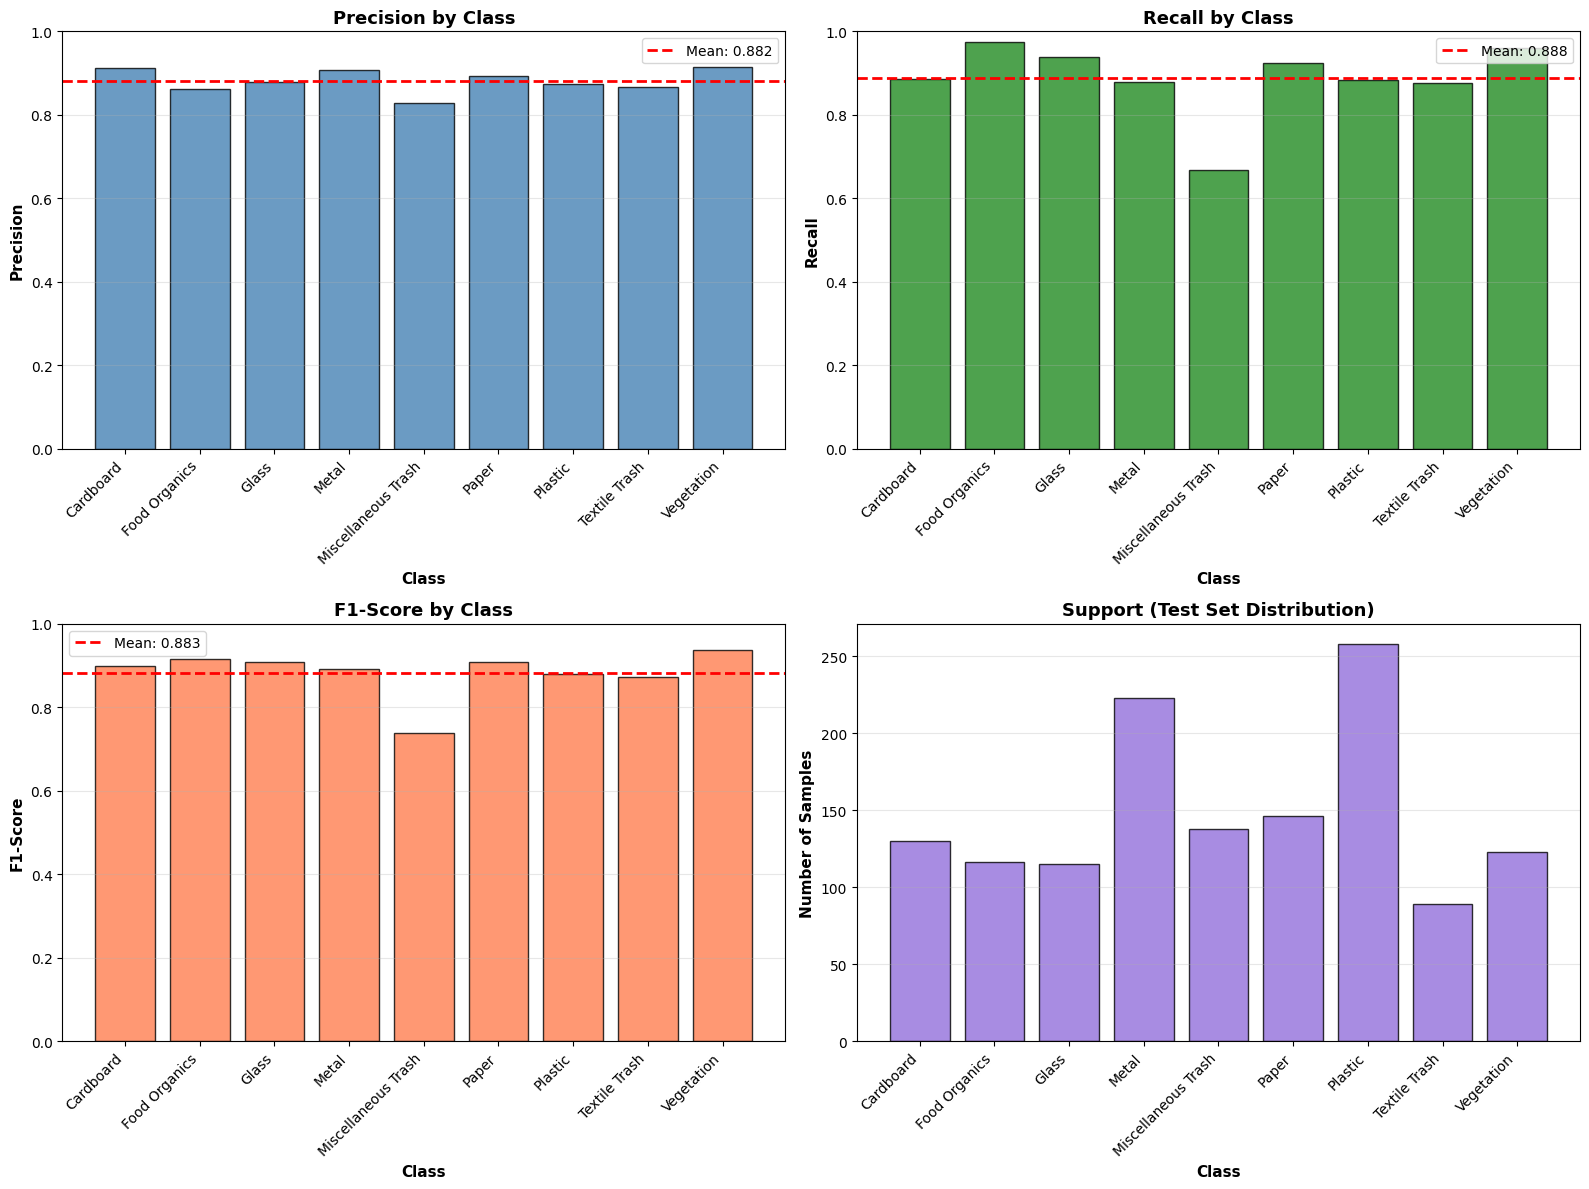

In [86]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

x_pos = np.arange(len(class_names))

# Precision
axes[0, 0].bar(x_pos, precision, color='steelblue', alpha=0.8, edgecolor='black')
axes[0, 0].set_xlabel('Class', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Precision', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Precision by Class', fontsize=13, fontweight='bold')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(class_names, rotation=45, ha='right')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].axhline(y=np.mean(precision), color='r', linestyle='--', linewidth=2, label=f'Mean: {np.mean(precision):.3f}')
axes[0, 0].legend()

# Recall
axes[0, 1].bar(x_pos, recall, color='forestgreen', alpha=0.8, edgecolor='black')
axes[0, 1].set_xlabel('Class', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Recall', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Recall by Class', fontsize=13, fontweight='bold')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(class_names, rotation=45, ha='right')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].axhline(y=np.mean(recall), color='r', linestyle='--', linewidth=2, label=f'Mean: {np.mean(recall):.3f}')
axes[0, 1].legend()

# F1-Score
axes[1, 0].bar(x_pos, f1, color='coral', alpha=0.8, edgecolor='black')
axes[1, 0].set_xlabel('Class', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('F1-Score', fontsize=11, fontweight='bold')
axes[1, 0].set_title('F1-Score by Class', fontsize=13, fontweight='bold')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(class_names, rotation=45, ha='right')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].axhline(y=np.mean(f1), color='r', linestyle='--', linewidth=2, label=f'Mean: {np.mean(f1):.3f}')
axes[1, 0].legend()

# Support (Test Set Distribution)
axes[1, 1].bar(x_pos, support, color='mediumpurple', alpha=0.8, edgecolor='black')
axes[1, 1].set_xlabel('Class', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Number of Samples', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Support (Test Set Distribution)', fontsize=13, fontweight='bold')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(class_names, rotation=45, ha='right')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PART1_DIR, 'performance_metrics.png'), dpi=300, bbox_inches='tight')
print(f"Performance metrics plot saved to {os.path.join(PART1_DIR, 'performance_metrics.png')}")
plt.show()

In [87]:
print('== Adam model (test) ==')
print(f'acc: {test_acc:.4f} | loss: {test_loss:.4f}')
print('top-3 classes by F1:')
best_f1_idx = np.argsort(f1)[-3:][::-1]
for idx in best_f1_idx:
    print(f'  {class_names[idx]} -> F1 {f1[idx]:.4f} (P {precision[idx]:.4f}, R {recall[idx]:.4f})')

print('bottom-3 classes by F1:')
worst_f1_idx = np.argsort(f1)[:3]
for idx in worst_f1_idx:
    print(f'  {class_names[idx]} -> F1 {f1[idx]:.4f} (P {precision[idx]:.4f}, R {recall[idx]:.4f})')

# common confusions (top-5)
misclassifications = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm[i, j] > 0:
            misclassifications.append((class_names[i], class_names[j], cm[i, j]))
misclassifications.sort(key=lambda x: x[2], reverse=True)
print('top-5 confusions:')
for true_cls, pred_cls, count in misclassifications[:5]:
    print(f'  {true_cls} -> {pred_cls}: {count}')

== Adam model (test) ==
acc: 0.8842 | loss: 0.3546
top-3 classes by F1:
  Vegetation -> F1 0.9365 (P 0.9147, R 0.9593)
  Food Organics -> F1 0.9150 (P 0.8626, R 0.9741)
  Paper -> F1 0.9091 (P 0.8940, R 0.9247)
bottom-3 classes by F1:
  Miscellaneous Trash -> F1 0.7390 (P 0.8288, R 0.6667)
  Textile Trash -> F1 0.8715 (P 0.8667, R 0.8764)
  Plastic -> F1 0.8786 (P 0.8736, R 0.8837)
top-5 confusions:
  Metal -> Plastic: 12
  Plastic -> Metal: 10
  Miscellaneous Trash -> Food Organics: 8
  Miscellaneous Trash -> Paper: 8
  Miscellaneous Trash -> Plastic: 7


## 17) Sample predictions

Sample predictions saved to results\part1\sample_predictions.png


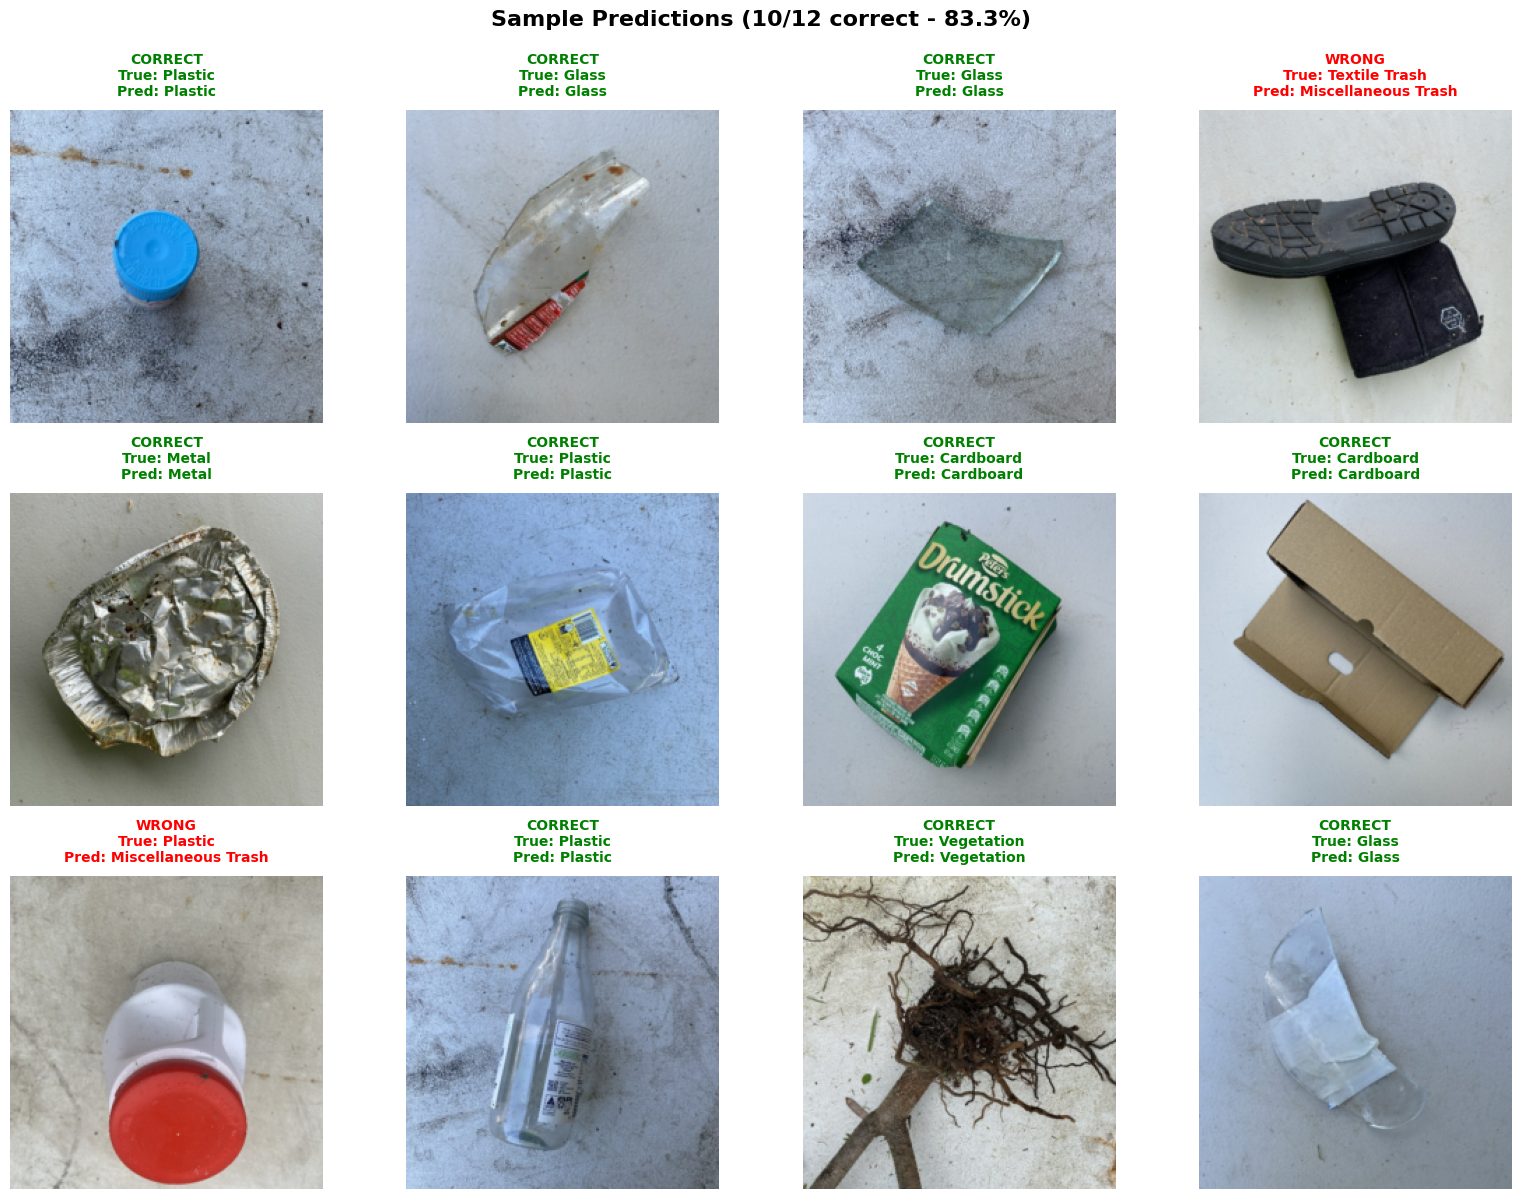

In [89]:
import random

def denormalize(tensor):
    """Denormalize image tensor for visualization"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    tensor = tensor * std + mean
    tensor = torch.clamp(tensor, 0, 1)
    return tensor

def show_predictions(model, test_dataset, class_names, device, num_samples=12):
    model.eval()
    indices = random.sample(range(len(test_dataset)), num_samples)

    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.ravel()

    correct_count = 0

    with torch.no_grad():
        for i, idx in enumerate(indices):
            image, true_label = test_dataset[idx]
            image_input = image.unsqueeze(0).to(device)

            output = model(image_input)
            _, predicted = torch.max(output, 1)
            pred_label = predicted.item()

            img_display = denormalize(image).permute(1, 2, 0).cpu().numpy()

            axes[i].imshow(img_display)
            axes[i].axis('off')

            is_correct = (pred_label == true_label)
            if is_correct:
                correct_count += 1
                color = 'green'
                status = 'CORRECT'
            else:
                color = 'red'
                status = 'WRONG'

            axes[i].set_title(f'{status}\nTrue: {class_names[true_label]}\nPred: {class_names[pred_label]}', 
                            color=color, fontsize=10, fontweight='bold', pad=10)

    plt.suptitle(f'Sample Predictions ({correct_count}/{num_samples} correct - {correct_count/num_samples*100:.1f}%)',
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig(os.path.join(PART1_DIR, 'sample_predictions.png'), dpi=300, bbox_inches='tight')
    print(f"Sample predictions saved to {os.path.join(PART1_DIR, 'sample_predictions.png')}")
    plt.show()

# Get the test dataset (without DataLoader)
from torchvision import datasets, transforms
test_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_dataset = datasets.ImageFolder(
    root=os.path.join(SPLIT_DATA_DIR, 'test'),
    transform=test_transform
)

show_predictions(best_model, test_dataset, class_names, DEVICE, num_samples=12)